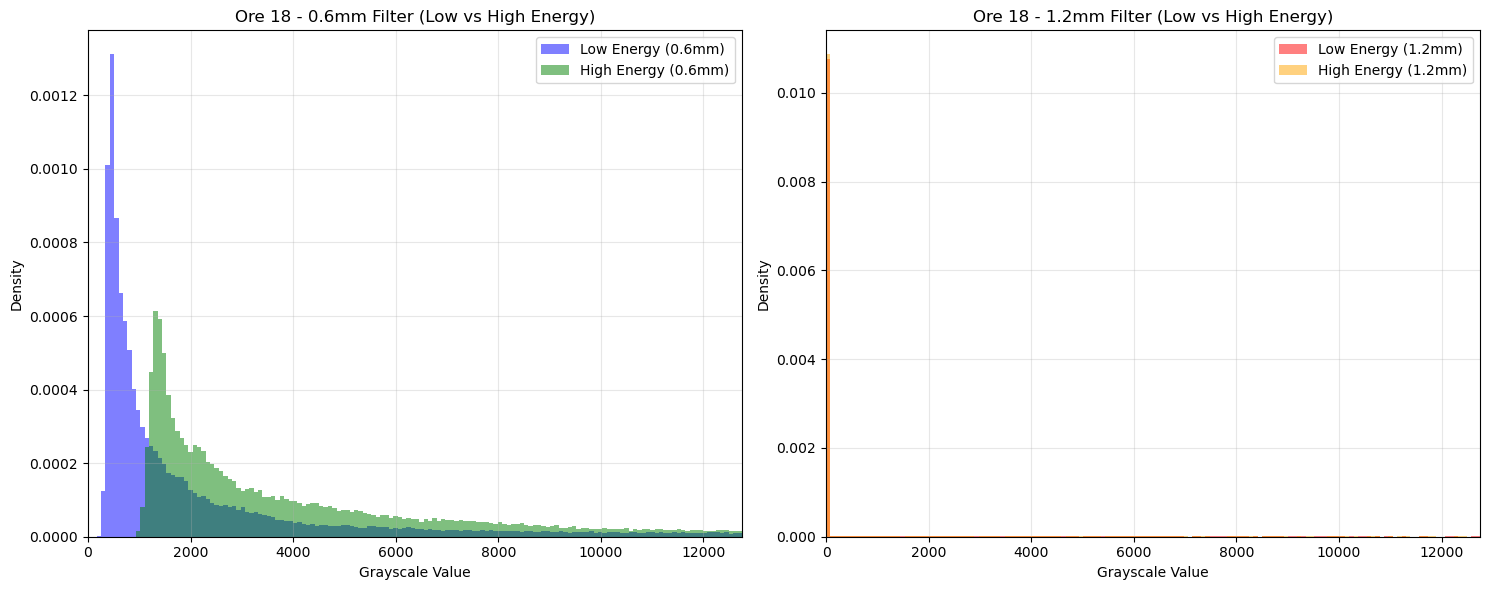

=== Ore 18 Statistics (200kV) ===

0.6mm Low Energy:
  Mean Grayscale: 3664.08
  Pixels == 0   : 0.00%
  Pixels < 10   : 0.00%
  Max Attenuation (u): 3.48

0.6mm High Energy:
  Mean Grayscale: 7139.85
  Pixels == 0   : 0.00%
  Pixels < 10   : 0.00%
  Max Attenuation (u): 2.51

1.2mm Low Energy:
  Mean Grayscale: 1301.94
  Pixels == 0   : 87.41%
  Pixels < 10   : 87.41%
  Max Attenuation (u): 9.76

1.2mm High Energy:
  Mean Grayscale: 2073.61
  Pixels == 0   : 85.45%
  Pixels < 10   : 85.45%
  Max Attenuation (u): 9.53


In [12]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import glob

# 配置目录和文件名 (以 200kV 为例)
input_dir = 'results/20260429_mask_generated_16bit/pixel_values'
file_06_pattern = f'{input_dir}/Ore-18-0.6mm-200kV-2mA-user_ore_0_data.pkl'
file_12_pattern = f'{input_dir}/Ore-18-1.2mm-200kV-2mA-user_ore_0_data.pkl'

file_06 = glob.glob(file_06_pattern)[0] if glob.glob(file_06_pattern) else None
file_12 = glob.glob(file_12_pattern)[0] if glob.glob(file_12_pattern) else None

def load_pixels(filepath):
    if not filepath:
        return np.array([]), np.array([])
    with open(filepath, 'rb') as f:
        d = pickle.load(f)
        p_low = d['pixels_low'][0] if isinstance(d['pixels_low'], list) else d['pixels_low']
        p_high = d['pixels_high'][0] if isinstance(d['pixels_high'], list) else d['pixels_high']
        return p_low, p_high

pixels_06_low, pixels_06_high = load_pixels(file_06)
pixels_12_low, pixels_12_high = load_pixels(file_12)

# 过滤掉异常值 (65535 或完全不在范围内的值)
def filter_valid(px):
    return px[(px >= 0) & (px < 65535)]

v_06_l = filter_valid(pixels_06_low)
v_06_h = filter_valid(pixels_06_high)
v_12_l = filter_valid(pixels_12_low)
v_12_h = filter_valid(pixels_12_high)

# 设置绘图横坐标上限
x_max = 50 * 255

# 创建画布 (1行2列)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ================== 1. 0.6mm 的高低能分布 ==================
axes[0].hist(v_06_l, bins=150, range=(0, x_max), alpha=0.5, label='Low Energy (0.6mm)', color='blue', density=True)
axes[0].hist(v_06_h, bins=150, range=(0, x_max), alpha=0.5, label='High Energy (0.6mm)', color='green', density=True)
axes[0].set_title("Ore 18 - 0.6mm Filter (Low vs High Energy)")
axes[0].set_xlabel("Grayscale Value")
axes[0].set_ylabel("Density")
axes[0].set_xlim(0, x_max)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ================== 2. 1.2mm 的高低能分布 ==================
axes[1].hist(v_12_l, bins=150, range=(0, x_max), alpha=0.5, label='Low Energy (1.2mm)', color='red', density=True)
axes[1].hist(v_12_h, bins=150, range=(0, x_max), alpha=0.5, label='High Energy (1.2mm)', color='orange', density=True)
axes[1].set_title("Ore 18 - 1.2mm Filter (Low vs High Energy)")
axes[1].set_xlabel("Grayscale Value")
axes[1].set_ylabel("Density")
axes[1].set_xlim(0, x_max)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ================== 3. 打印关键统计信息 ==================
print("=== Ore 18 Statistics (200kV) ===")
datasets = [
    ("0.6mm Low Energy", v_06_l),
    ("0.6mm High Energy", v_06_h),
    ("1.2mm Low Energy", v_12_l),
    ("1.2mm High Energy", v_12_h)
]

for name, valid_px in datasets:
    if len(valid_px) > 0:
        zero_ratio = np.sum(valid_px == 0) / len(valid_px) * 100
        low_ratio = np.sum(valid_px < 10) / len(valid_px) * 100
        print(f"\n{name}:")
        print(f"  Mean Grayscale: {np.mean(valid_px):.2f}")
        print(f"  Pixels == 0   : {zero_ratio:.2f}%")
        print(f"  Pixels < 10   : {low_ratio:.2f}%")
        print(f"  Max Attenuation (u): {np.mean(np.log(52428.0 / np.maximum(valid_px, 1.0))):.2f}")
